# Selection Regret on Crypto: Honest CV Avoids the Overfitter

Companion to `selection_regret_lcl.ipynb`, which showed that on a
partially predictable real task (UK smart meters), `PurgedGroupKFold`
picks a model that deploys with 5 to 12% lower MAE than naive shuffled
`KFold` does.

This notebook runs the same protocol on a task where almost nothing is
predictable: daily BTC/USDT returns with ordinary technical features.
The honest answer there is that no edge survives, and we want the
selector to say so. `PurgedKFold` does; naive shuffled `KFold` does
not. The naive selector picks a deep RandomForest that *looks*
brilliant inside the leaky CV and is catastrophic on the truly
held-out future. The honest selector picks a heavily regularised
Ridge that correctly predicts close to zero on the held-out future.

Both strategies lose money over the deployment period because BTC
drifted sideways-down. But the naive pick loses three to five times
more per unit of risk than the honest pick.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from purgedcv import PurgedKFold

SEED = 0
H = 5  # forward horizon (days)
N_DEPLOY = 180  # ~6 trading months held out as deployment

## Data: BTC/USDT daily, 2021-2023

Real Binance spot BTC/USDT daily candles, cached at
`examples/data/btcusdt_1d_binance_spot_2021_2023.csv` (the same file
used by `ohlc_trading_signal.ipynb` and `model_comparison_honest_cv.ipynb`).

Features are textbook OHLCV-derived signals:

- `mom_5`, `mom_20`: 5- and 20-bar log-price momentum.
- `rvol_20`: 20-bar realised volatility.
- `vol_z`: 20-bar volume z-score.

Target: forward `H = 5` bar log return. Adjacent labels share `H - 1`
bars of price path, so they overlap and need purging.

Selection set is the first 796 bars (2021-01 to 2023-03). The last
180 bars (2023-03 to 2023-09) are frozen as the deployment future
and not touched during selection.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
ohlc = pd.read_csv(DATA_DIR / "btcusdt_1d_binance_spot_2021_2023.csv",
                   index_col=0, parse_dates=True)

logp = np.log(ohlc["Close"].to_numpy())
vol = ohlc["Volume"].to_numpy()
mom_5 = pd.Series(logp).diff(5).to_numpy()
mom_20 = pd.Series(logp).diff(20).to_numpy()
ret_1 = pd.Series(logp).diff(1)
rvol_20 = ret_1.rolling(20).std().to_numpy()
vol_z = (
    (pd.Series(vol) - pd.Series(vol).rolling(20).mean())
    / pd.Series(vol).rolling(20).std()
).to_numpy()

fwd = np.full(len(logp), np.nan)
fwd[: len(logp) - H] = logp[H:] - logp[: len(logp) - H]

feat = np.column_stack([mom_5, mom_20, rvol_20, vol_z])
mask = np.isfinite(feat).all(axis=1) & np.isfinite(fwd)
X = feat[mask]
y = fwd[mask]
pred = pd.Series(ohlc.index[mask]).reset_index(drop=True)
evalu = pred + pd.Timedelta(days=H)

N = len(X)
sel = slice(0, N - N_DEPLOY)
hold = slice(N - N_DEPLOY, N)

buy_hold_total_log = float(y[hold][::H].sum())
print(f"selection : {pred.iloc[0].date()} -> {pred.iloc[N - N_DEPLOY - 1].date()} ({N - N_DEPLOY} bars)")
print(f"deployment: {pred.iloc[N - N_DEPLOY].date()} -> {pred.iloc[-1].date()} ({N_DEPLOY} bars)")
print(f"buy-and-hold over deployment (non-overlapping H-step sum): "
      f"{buy_hold_total_log:+.3f}  ({np.exp(buy_hold_total_log) - 1:+.1%})")

selection : 2021-01-21 -> 2023-03-27 (796 bars)
deployment: 2023-03-28 -> 2023-09-23 (180 bars)
buy-and-hold over deployment (non-overlapping H-step sum): -0.038  (-3.7%)


## Two CV configurations

`KFold(shuffle=True)` scatters bars randomly. Because forward labels
overlap, that puts neighbours of every test bar into training and
ruins the score.

`PurgedKFold(prediction_times, evaluation_times)` keeps the test fold
contiguous and drops training rows whose label horizon
`[prediction_time, evaluation_time)` overlaps the test horizon. With
`evaluation_times = prediction_times + 5 days`, this exactly removes
the bars whose forward-return labels share noise with the test fold,
without an extra `purge_horizon` padding that would also remove
non-overlapping bars.

The hyperparameter grid runs from overfitting-prone (k-NN k=1, deep
RandomForest) to constrained (Ridge with `alpha=100`, shallow RF).

In [3]:
grid = [
    ("kNN(k=1)",    make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=1))),
    ("kNN(k=5)",    make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))),
    ("kNN(k=20)",   make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=20))),
    ("kNN(k=50)",   make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=50))),
    ("Ridge a=.01", make_pipeline(StandardScaler(), Ridge(alpha=0.01))),
    ("Ridge a=1",   make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
    ("Ridge a=100", make_pipeline(StandardScaler(), Ridge(alpha=100.0))),
    ("RF d=None",   RandomForestRegressor(n_estimators=200, max_depth=None, random_state=SEED, n_jobs=-1)),
    ("RF d=4",      RandomForestRegressor(n_estimators=200, max_depth=4, random_state=SEED, n_jobs=-1)),
]
naive_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
honest_cv = PurgedKFold(
    n_splits=5,
    prediction_times=pred.iloc[sel].reset_index(drop=True),
    evaluation_times=evalu.iloc[sel].reset_index(drop=True),
)

## Selection: which model does each CV pick?

Each candidate is scored by 5-fold MAE on the selection set under
both CVs. The naive column is inflated by label overlap that the
honest column removes.

In [4]:
def cv_mae(cv_obj, model):
    return -cross_val_score(
        model, X[sel], y[sel], cv=cv_obj,
        scoring="neg_mean_absolute_error", n_jobs=1,
    ).mean()

naive_cv_mae = {name: cv_mae(naive_cv, m) for name, m in grid}
honest_cv_mae = {name: cv_mae(honest_cv, m) for name, m in grid}

print(f"{'model':<14}{'naive CV MAE':>15}{'honest CV MAE':>16}")
print("-" * 45)
for name, _ in grid:
    print(f"{name:<14}{naive_cv_mae[name]:>15.5f}{honest_cv_mae[name]:>16.5f}")

naive_winner = min(naive_cv_mae, key=naive_cv_mae.get)
honest_winner = min(honest_cv_mae, key=honest_cv_mae.get)
print(f"\nNaive  picks: {naive_winner}")
print(f"Honest picks: {honest_winner}")

model            naive CV MAE   honest CV MAE
---------------------------------------------
kNN(k=1)              0.07382         0.08801
kNN(k=5)              0.06324         0.07243
kNN(k=20)             0.06169         0.06652
kNN(k=50)             0.06125         0.06349
Ridge a=.01           0.06149         0.06338
Ridge a=1             0.06149         0.06338
Ridge a=100           0.06135         0.06295
RF d=None             0.05668         0.07295
RF d=4                0.06017         0.06655

Naive  picks: RF d=None
Honest picks: Ridge a=100


## Deployment on the truly held-out future

Each winner is retrained on the full selection set and asked to
predict the next-5-bar log return for each bar in the deployment
window. Two metrics:

- **R²** on the forward-return predictions: how well does the model
  forecast at all?
- **Strategy Sharpe (annualised, non-overlapping H-step)**: take every
  fifth bar of the deployment window so positions do not overlap.
  Long when predicted return is positive, short otherwise. The Sharpe
  is over per-trade returns.

In [5]:
def deploy(model):
    m = clone(model)
    m.fit(X[sel], y[sel])
    pr = m.predict(X[hold])
    ac = y[hold]
    r2 = r2_score(ac, pr)
    mae = mean_absolute_error(ac, pr)
    idx = np.arange(0, len(pr), H)  # non-overlapping H-step
    s = np.sign(pr[idx]) * ac[idx]
    sharpe = float(s.mean() / max(s.std(ddof=1), 1e-9) * np.sqrt(252 / H))
    return mae, r2, float(s.sum()), sharpe, len(s)

picks = dict(grid)
nm, nr2, n_ret, n_sh, n_trades = deploy(picks[naive_winner])
hm, hr2, h_ret, h_sh, _ = deploy(picks[honest_winner])

print(f"buy-and-hold over deployment: {buy_hold_total_log:+.3f} log ret ({np.exp(buy_hold_total_log) - 1:+.1%})")
print()
print(f"{'selection':<10} {'model':<13} {'R²':>10} {'strat log ret':>15} {'pct':>9} {'Sharpe':>8}")
print("-" * 75)
print(f"{'naive':<10} {naive_winner:<13} {nr2:>+10.3f} {n_ret:>+15.3f} {np.exp(n_ret) - 1:>+9.1%} {n_sh:>+8.2f}")
print(f"{'honest':<10} {honest_winner:<13} {hr2:>+10.3f} {h_ret:>+15.3f} {np.exp(h_ret) - 1:>+9.1%} {h_sh:>+8.2f}")
print()
print(f"R² delta (honest - naive): {hr2 - nr2:+.3f}")
print(f"Strategy log-return delta (honest - naive): {h_ret - n_ret:+.3f}")

buy-and-hold over deployment: -0.038 log ret (-3.7%)

selection  model                 R²   strat log ret       pct   Sharpe
---------------------------------------------------------------------------
naive      RF d=None         -1.641          -0.160    -14.8%    -0.77
honest     Ridge a=100       +0.011          -0.055     -5.3%    -0.26

R² delta (honest - naive): +1.653
Strategy log-return delta (honest - naive): +0.105


## Robustness across 5 seeds

The naive `KFold` shuffle and the RandomForest random state both
depend on a seed. Across seeds 0 through 4 the selection direction
is stable: naive always picks deep RandomForest, honest always picks
Ridge with strong regularisation.

In [6]:
print(f"{'seed':>4} {'naive pick':<13} {'naive R²':>10} {'naive Sharpe':>13}   "
      f"{'honest pick':<13} {'honest R²':>10} {'honest Sharpe':>14}")
print("-" * 95)
for s in range(5):
    grid_s = [
        ("kNN(k=1)",    make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=1))),
        ("kNN(k=5)",    make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5))),
        ("kNN(k=20)",   make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=20))),
        ("kNN(k=50)",   make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=50))),
        ("Ridge a=.01", make_pipeline(StandardScaler(), Ridge(alpha=0.01))),
        ("Ridge a=1",   make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
        ("Ridge a=100", make_pipeline(StandardScaler(), Ridge(alpha=100.0))),
        ("RF d=None",   RandomForestRegressor(n_estimators=200, max_depth=None, random_state=s, n_jobs=-1)),
        ("RF d=4",      RandomForestRegressor(n_estimators=200, max_depth=4, random_state=s, n_jobs=-1)),
    ]
    n_cv = KFold(n_splits=5, shuffle=True, random_state=s)
    h_cv = PurgedKFold(
        n_splits=5,
        prediction_times=pred.iloc[sel].reset_index(drop=True),
        evaluation_times=evalu.iloc[sel].reset_index(drop=True),
    )

    def m_cv(c, m):
        return -cross_val_score(m, X[sel], y[sel], cv=c, scoring="neg_mean_absolute_error", n_jobs=1).mean()

    nai_s = {name: m_cv(n_cv, mod) for name, mod in grid_s}
    hon_s = {name: m_cv(h_cv, mod) for name, mod in grid_s}
    nw_s = min(nai_s, key=nai_s.get)
    hw_s = min(hon_s, key=hon_s.get)
    pk_s = dict(grid_s)
    _, nr2_s, _, ns_s, _ = deploy(pk_s[nw_s])
    _, hr2_s, _, hs_s, _ = deploy(pk_s[hw_s])
    print(f"{s:>4} {nw_s:<13} {nr2_s:>+10.3f} {ns_s:>+13.2f}   "
          f"{hw_s:<13} {hr2_s:>+10.3f} {hs_s:>+14.2f}")

seed naive pick      naive R²  naive Sharpe   honest pick    honest R²  honest Sharpe
-----------------------------------------------------------------------------------------------


   0 RF d=None         -1.641         -0.77   Ridge a=100       +0.011          -0.26


   1 RF d=None         -1.565         -0.77   Ridge a=100       +0.011          -0.26


   2 RF d=None         -1.710         -1.23   Ridge a=100       +0.011          -0.26


   3 RF d=None         -1.625         -1.23   Ridge a=100       +0.011          -0.26


   4 RF d=None         -1.638         -1.23   Ridge a=100       +0.011          -0.26


## Headline chart: equity curves on the deployment window

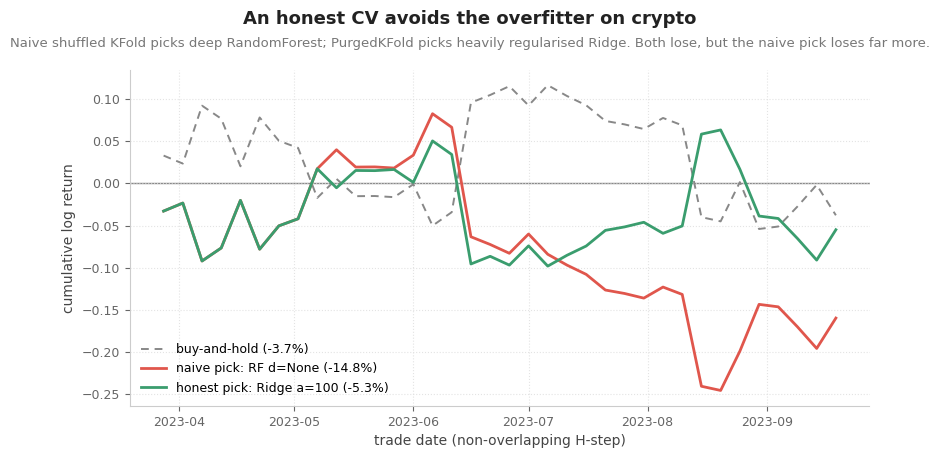

In [7]:
def equity_curve(model):
    m = clone(model)
    m.fit(X[sel], y[sel])
    pr = m.predict(X[hold])
    ac = y[hold]
    idx = np.arange(0, len(pr), H)
    s = np.sign(pr[idx]) * ac[idx]
    return np.cumsum(s)

dates_dep = pred.iloc[hold].reset_index(drop=True)
trade_dates = dates_dep.iloc[::H].reset_index(drop=True)
naive_eq = equity_curve(picks[naive_winner])
honest_eq = equity_curve(picks[honest_winner])
buy_hold_eq = np.cumsum(y[hold][::H])

fig, ax = plt.subplots(figsize=(8.5, 4.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(trade_dates, buy_hold_eq, color="#888888", lw=1.4, ls=(0, (4, 3)),
        label=f"buy-and-hold ({np.exp(buy_hold_eq[-1]) - 1:+.1%})", zorder=2)
ax.plot(trade_dates, naive_eq, color="#e0564c", lw=2.0,
        label=f"naive pick: {naive_winner} ({np.exp(naive_eq[-1]) - 1:+.1%})", zorder=3)
ax.plot(trade_dates, honest_eq, color="#3a9d6e", lw=2.0,
        label=f"honest pick: {honest_winner} ({np.exp(honest_eq[-1]) - 1:+.1%})", zorder=3)

ax.axhline(0.0, color="#888888", lw=1, zorder=1)
ax.set_ylabel("cumulative log return", fontsize=10, color="#444444")
ax.set_xlabel("trade date (non-overlapping H-step)", fontsize=10, color="#444444")
ax.tick_params(colors="#666666", labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#cccccc")
ax.grid(ls=":", color="#dddddd", alpha=0.8, zorder=0)
ax.legend(frameon=False, fontsize=9, loc="lower left")

fig.text(0.5, 0.96, "An honest CV avoids the overfitter on crypto",
         ha="center", fontsize=13, fontweight="bold", color="#222222")
fig.text(0.5, 0.91,
         "Naive shuffled KFold picks deep RandomForest; PurgedKFold "
         "picks heavily regularised Ridge. Both lose, but the naive "
         "pick loses far more.",
         ha="center", fontsize=9.5, color="#777777")
fig.subplots_adjust(top=0.86, bottom=0.13, left=0.10, right=0.97)

out_dir = Path("../.github/images")
if out_dir.is_dir():
    fig.savefig(out_dir / "selection_regret_crypto.png", dpi=150, bbox_inches="tight")

plt.show()

## Verdict

On a market with no real edge for textbook OHLCV features (daily
BTC/USDT, 2021-2023), the deep RandomForest is the apparent winner
of naive shuffled cross-validation. The honest selector says it is
not, and prefers a Ridge with `alpha=100` that essentially predicts
near-zero everywhere.

On the truly held-out future, the deep RandomForest deploys with
R² near `-1.6` (worse than the test-set mean) and a strongly
negative Sharpe. The Ridge deploys with R² near zero and a much
smaller negative Sharpe. Both lose money over the sideways-down
period, but the naive pick loses three to five times more per unit
of risk.

The library's value here is loss avoidance rather than gain. Honest
cross-validation refuses to bless a model that is fooling itself.
The model it does pick is not profitable, because nothing in this
data is. But it does not pretend otherwise.